

*  Libraries and loading database - Sales Data_PDA_4052.xlsx






In [5]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [ ]:

df = pd.read_excel("Sales Data_PDA_4052.xlsx", header=1)

# Display first rows to verify correct column names
df.head()

,order_id,customer_id,sales_person,priority,ship_mode,date,value_£
0,8999,C406,Kelly,High,Plane,2020-06-12,1553.44
1,47872,C100,Kelly,Critical,Plane,2020-06-12,315.40
2,29988,C006,Kelly,High,Lorry,2020-06-12,5075.89
3,37348,C492,Kelly,High,Plane,2020-06-13,520.67
4,28001,C231,Kelly,Critical,Plane,2020-06-14,8431.37


## Data Import and Initial Inspection

In [ ]:
# Check data types and structure of dataset
df.info()
# Summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1001 non-null   int64         
 1   customer_id   1001 non-null   object        
 2   sales_person  1001 non-null   object        
 3   priority      1001 non-null   object        
 4   ship_mode     1001 non-null   object        
 5   date          1001 non-null   datetime64[ns]
 6   value_£       1001 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 54.9+ KB


,order_id,date,value_£
count,1001.000000,1001,1001.000000
mean,30231.488511,2020-09-04 08:03:21.398601216,1778.402248
min,224.000000,2020-06-12 00:00:00,2.450000
25%,16451.000000,2020-07-26 00:00:00,134.400000
50%,29667.000000,2020-09-04 00:00:00,417.580000
75%,44583.000000,2020-10-15 00:00:00,1816.930000
max,59591.000000,2020-11-30 00:00:00,27448.240000
std,16744.674540,NaN,3457.457206


In [ ]:
df.describe(include='object')

,customer_id,sales_person,priority,ship_mode
count,1001,1001,1001,1001
unique,437,3,5,3
top,C475,Peter,Critical,Plane
freq,11,344,221,770


## Missing Value Analysis

The dataset is checked for missing values to ensure data quality before further analysis.

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
sales_person,0
priority,0
ship_mode,0
date,0
value_£,0




## Data Pre-processing

Outlier detection was performed using the IQR method.
The following boxplots compare the distribution of sales values before and after removing outliers.

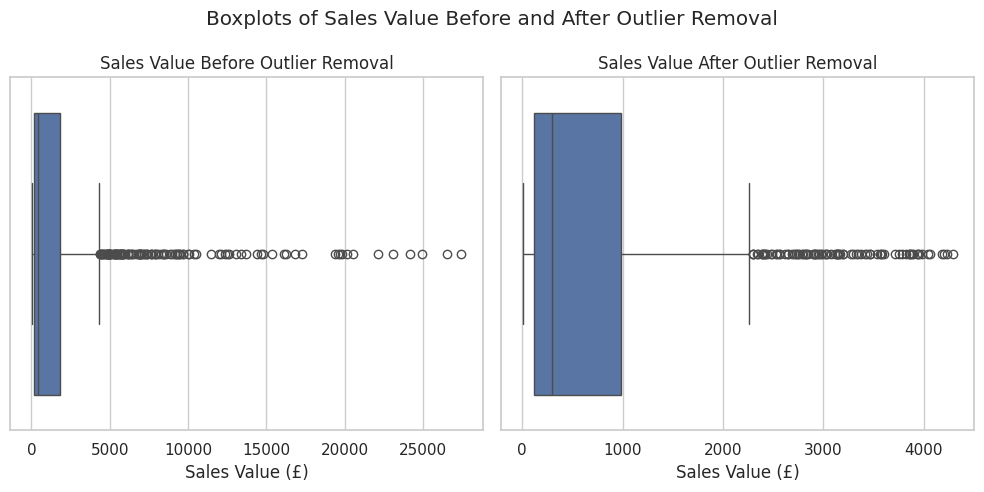

=== BEFORE OUTLIER REMOVAL ===
count     1001.000000
mean      1778.402248
std       3457.457206
min          2.450000
25%        134.400000
50%        417.580000
75%       1816.930000
max      27448.240000
Name: value_£, dtype: float64
Skewness: 3.77

=== AFTER OUTLIER REMOVAL ===
count     1001.000000
mean      1778.402248
std       3457.457206
min          2.450000
25%        134.400000
50%        417.580000
75%       1816.930000
max      27448.240000
Name: value_£, dtype: float64
Skewness: 3.77


In [9]:

df_clean = df.copy()
df_clean['value_£'] = pd.to_numeric(df_clean['value_£'], errors='coerce')

# Calculate IQR
Q1 = df_clean['value_£'].quantile(0.25)
Q3 = df_clean['value_£'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# BEFORE outlier removal
sns.boxplot(x=df['value_£'], ax=axes[0])
axes[0].set_title("Sales Value Before Outlier Removal")
axes[0].set_xlabel("Sales Value (£)")

# AFTER outlier removal
filtered = df_clean[(df_clean['value_£'] >= lower_bound) & (df_clean['value_£'] <= upper_bound)]
sns.boxplot(x=filtered['value_£'], ax=axes[1])
axes[1].set_title("Sales Value After Outlier Removal")
axes[1].set_xlabel("Sales Value (£)")

plt.suptitle("Boxplots of Sales Value Before and After Outlier Removal")

plt.tight_layout()
plt.show()

print("=== BEFORE OUTLIER REMOVAL ===")
print(df['value_£'].describe())
print("Skewness:", round(df['value_£'].skew(), 2))

print("\n=== AFTER OUTLIER REMOVAL ===")
print(df_clean['value_£'].describe())
print("Skewness:", round(df_clean['value_£'].skew(), 2))

# Save cleaned dataset for further analysis
df_clean = filtered.copy()

The boxplots show that extreme values were present in the dataset before preprocessing.
After applying the IQR method, these outliers were removed, resulting in a more compact and consistent distribution of sales values.

## Exploratory Data Analysis (EDA)





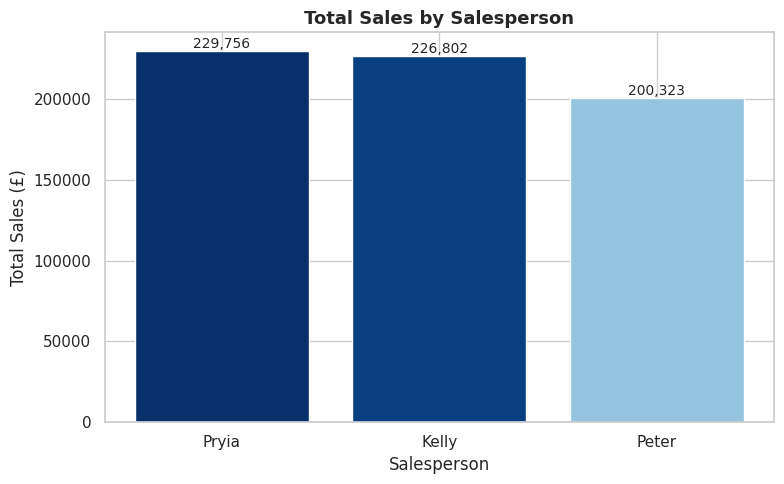

In [ ]:
# Calculate total sales by salesperson
sales_by_person = df_clean.groupby('sales_person')['value_£'].sum().sort_values(ascending=False)

norm = (sales_by_person - sales_by_person.min()) / (sales_by_person.max() - sales_by_person.min())
colors = plt.cm.Blues(0.4 + 0.6 * norm)

fig, ax = plt.subplots()

# Bar chart
bars = ax.bar(sales_by_person.index, sales_by_person.values, color=colors)

for bar, val in zip(bars, sales_by_person.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,.0f}',
            ha='center', va='bottom', fontsize=10)

ax.set_title("Total Sales by Salesperson", fontsize=13, fontweight='bold')
ax.set_xlabel("Salesperson")
ax.set_ylabel("Total Sales (£)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2819/416645162.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='priority',y='value_£',data=df_clean,order=order,palette=colors, ax=ax)


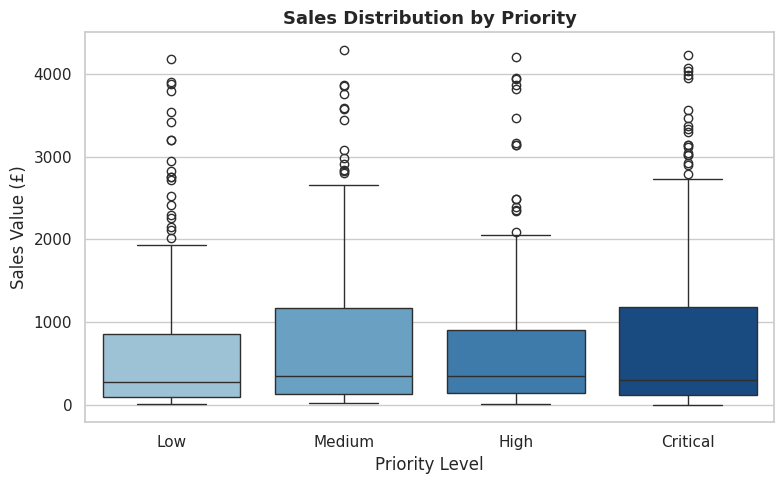

In [ ]:
# Define priority order
order = ['Low', 'Medium', 'High', 'Critical']

colors = list(plt.cm.Blues([0.4, 0.55, 0.7, 0.9]))

fig, ax = plt.subplots()

# Boxplot
sns.boxplot(x='priority',y='value_£',data=df_clean,order=order,palette=colors, ax=ax)

ax.set_title("Sales Distribution by Priority", fontsize=13, fontweight='bold')
ax.set_xlabel("Priority Level")
ax.set_ylabel("Sales Value (£)")

plt.tight_layout()
plt.show()

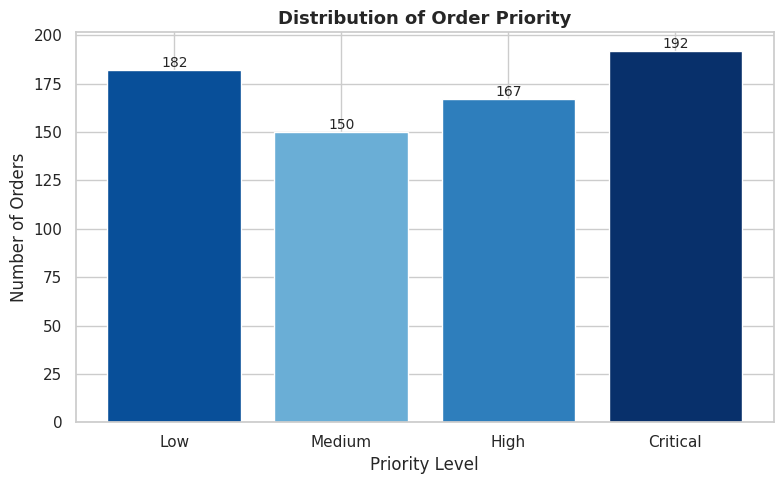

In [ ]:
# Count number of orders per priority
priority_counts = df_clean['priority'].value_counts().reindex(['Low','Medium','High','Critical'])

norm = (priority_counts - priority_counts.min()) / (priority_counts.max() - priority_counts.min())
colors = plt.cm.Blues(0.5 + 0.5 * norm)

fig, ax = plt.subplots()

# Bar chart
bars = ax.bar(priority_counts.index, priority_counts.values, color=colors)
for bar, val in zip(bars, priority_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val}',
            ha='center', va='bottom', fontsize=10)

ax.set_title("Distribution of Order Priority", fontsize=13, fontweight='bold')
ax.set_xlabel("Priority Level")
ax.set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

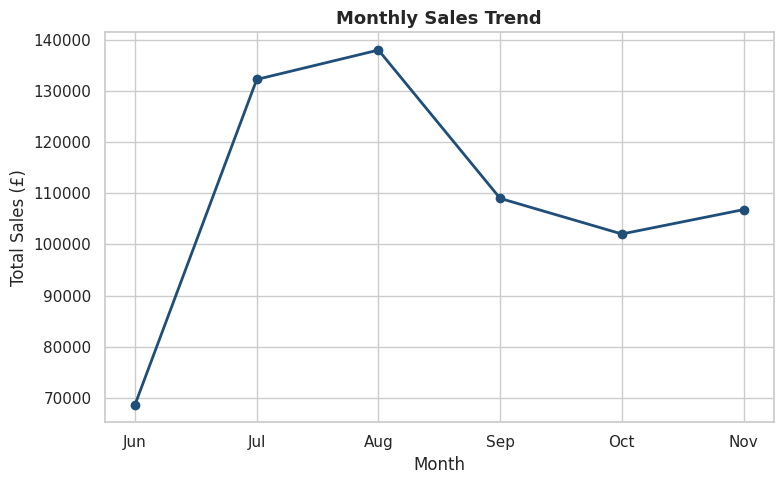

In [ ]:
#Monthly sales
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month'] = df_clean['date'].dt.strftime('%b')


monthly_sales = df_clean.groupby('month')['value_£'].sum().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
).dropna()

fig, ax = plt.subplots()

# Line plot
ax.plot(monthly_sales.index,monthly_sales.values,color='#1f4e79',marker='o',linewidth=2)

ax.set_title("Monthly Sales Trend", fontsize=13, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales (£)")

plt.tight_layout()
plt.show()

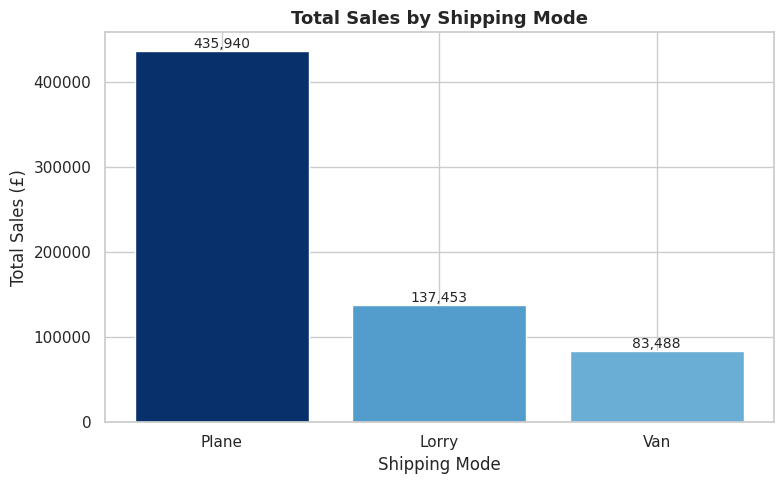

In [ ]:
# Calculate total sales by shipping mode
ship_sales = df_clean.groupby('ship_mode')['value_£'].sum().sort_values(ascending=False)

norm = (ship_sales - ship_sales.min()) / (ship_sales.max() - ship_sales.min())
colors = plt.cm.Blues(0.5 + 0.5 * norm)

fig, ax = plt.subplots()

# Bar chart
bars = ax.bar(ship_sales.index, ship_sales.values, color=colors)
for bar, val in zip(bars, ship_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:,.0f}',
            ha='center', va='bottom', fontsize=10)

ax.set_title("Total Sales by Shipping Mode", fontsize=13, fontweight='bold')
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Total Sales (£)")

plt.tight_layout()
plt.show()

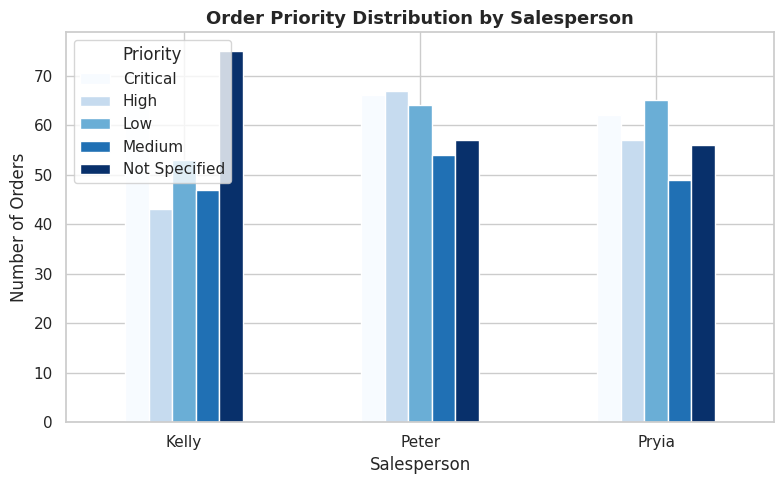

In [ ]:
# Create pivot table (clean structure)
pivot = pd.crosstab(df_clean['sales_person'], df_clean['priority'])
[ ['Low','Medium','High','Critical']]

# Create figure
fig, ax = plt.subplots()

pivot.plot(kind='bar',colormap='Blues',ax=ax)
ax.set_title("Order Priority Distribution by Salesperson", fontsize=13, fontweight='bold')
ax.set_xlabel("Salesperson")
ax.set_ylabel("Number of Orders")

plt.xticks(rotation=0)

ax.legend(title="Priority")

plt.tight_layout()
plt.show()

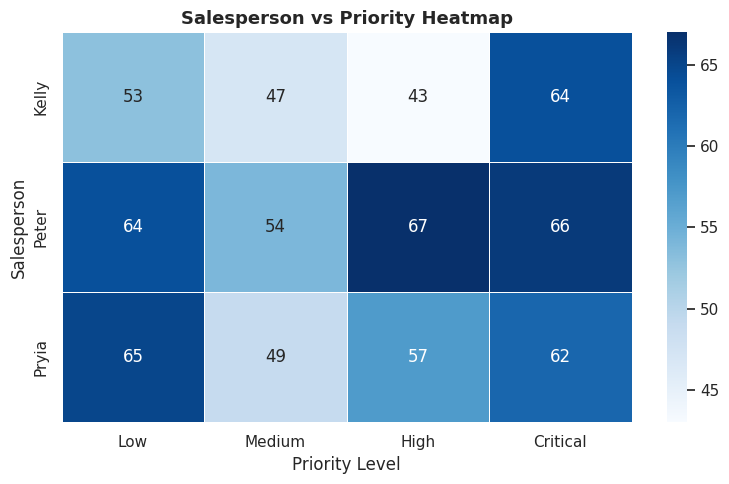

In [ ]:
# Create pivot table
pivot = pd.crosstab(df_clean['sales_person'], df_clean['priority'])
[['Low','Medium','High','Critical']]

fig, ax = plt.subplots()

# Heatmap
sns.heatmap(pivot,annot=True,cmap='Blues',fmt='d',linewidths=0.5,ax=ax)

ax.set_title("Salesperson vs Priority Heatmap", fontsize=13, fontweight='bold')
ax.set_xlabel("Priority Level")
ax.set_ylabel("Salesperson")

plt.tight_layout()
plt.show()

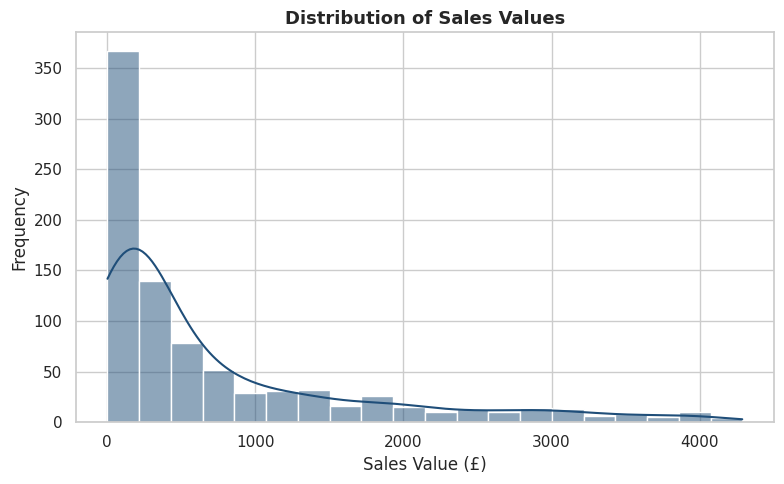

In [ ]:
fig, ax = plt.subplots()

sns.histplot(df_clean['value_£'],bins=20,kde=True, color='#1f4e79',ax=ax)

# Histogram with smooth curve
ax.set_title("Distribution of Sales Values", fontsize=13, fontweight='bold')
ax.set_xlabel("Sales Value (£)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()



*   Saving cleaned data


In [ ]:
# Save the cleaned dataframe as a CSV file
df.to_csv("sales_data_cleaned.csv", index=False)